In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/store-sales-time-series-forecasting/oil.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/sample_submission.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/holidays_events.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/stores.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/train.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/test.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/transactions.csv


In [2]:
import kagglehub
kagglehub.competition_download('store-sales-time-series-forecasting')

'/kaggle/input/competitions/store-sales-time-series-forecasting'

In [3]:
df_train = pd.read_csv("/kaggle/input/competitions/store-sales-time-series-forecasting/train.csv")
df_train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [4]:
df_train.shape

(3000888, 6)

In [5]:
df_test = pd.read_csv("/kaggle/input/competitions/store-sales-time-series-forecasting/test.csv")
df_test.head()

,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0


- store_nbr identifies the store at which the products are sold.
- family identifies the type of product sold.
- sales gives the total sales for a product family at a particular store at a given date. Fractional values are possible since products can be sold in fractional units (1.5 kg of cheese, for instance, as opposed to 1 bag of chips).
- onpromotion gives the total number of items in a product family that were being promoted at a store at a given date.

In [6]:
df_train.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [7]:
# Check for null data
df_train.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [8]:
data_store = pd.read_csv('/kaggle/input/competitions/store-sales-time-series-forecasting/stores.csv')
data_oil = pd.read_csv('/kaggle/input/competitions/store-sales-time-series-forecasting/oil.csv')
data_trans = pd.read_csv('/kaggle/input/competitions/store-sales-time-series-forecasting/transactions.csv')
data_holi = pd.read_csv('/kaggle/input/competitions/store-sales-time-series-forecasting/holidays_events.csv')
data_train = pd.read_csv("/kaggle/input/competitions/store-sales-time-series-forecasting/train.csv")

def news(df, name="DataFrame"):
    print(f'The top 5 rows of {name}\n')
    print(df.head())
    
    print(15*'-')
    print(f'The shape of {name}')
    print(df.shape)
    
    print(15*'-')
    print(f'The description of {name}')
    print(15*'-')
    print(df.describe())

    print(15*'-')
    print(f'Sum of null values {name}')
    print(15*'-')
    print(df.isnull().sum())

In [9]:
news(data_store)

The top 5 rows of DataFrame

   store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4
---------------
The shape of DataFrame
(54, 5)
---------------
The description of DataFrame
---------------
       store_nbr    cluster
count  54.000000  54.000000
mean   27.500000   8.481481
std    15.732133   4.693395
min     1.000000   1.000000
25%    14.250000   4.000000
50%    27.500000   8.500000
75%    40.750000  13.000000
max    54.000000  17.000000
---------------
Sum of null values DataFrame
---------------
store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64


In [10]:
news(data_oil)

The top 5 rows of DataFrame

         date  dcoilwtico
0  2013-01-01         NaN
1  2013-01-02       93.14
2  2013-01-03       92.97
3  2013-01-04       93.12
4  2013-01-07       93.20
---------------
The shape of DataFrame
(1218, 2)
---------------
The description of DataFrame
---------------
        dcoilwtico
count  1175.000000
mean     67.714366
std      25.630476
min      26.190000
25%      46.405000
50%      53.190000
75%      95.660000
max     110.620000
---------------
Sum of null values DataFrame
---------------
date           0
dcoilwtico    43
dtype: int64


So the oil dataframe have some null values.

In [11]:
news(data_trans)

The top 5 rows of DataFrame

         date  store_nbr  transactions
0  2013-01-01         25           770
1  2013-01-02          1          2111
2  2013-01-02          2          2358
3  2013-01-02          3          3487
4  2013-01-02          4          1922
---------------
The shape of DataFrame
(83488, 3)
---------------
The description of DataFrame
---------------
          store_nbr  transactions
count  83488.000000  83488.000000
mean      26.939237   1694.602158
std       15.608204    963.286644
min        1.000000      5.000000
25%       13.000000   1046.000000
50%       27.000000   1393.000000
75%       40.000000   2079.000000
max       54.000000   8359.000000
---------------
Sum of null values DataFrame
---------------
date            0
store_nbr       0
transactions    0
dtype: int64


In [12]:
news(data_holi)

The top 5 rows of DataFrame

         date     type    locale locale_name                    description  \
0  2012-03-02  Holiday     Local       Manta             Fundacion de Manta   
1  2012-04-01  Holiday  Regional    Cotopaxi  Provincializacion de Cotopaxi   
2  2012-04-12  Holiday     Local      Cuenca            Fundacion de Cuenca   
3  2012-04-14  Holiday     Local    Libertad      Cantonizacion de Libertad   
4  2012-04-21  Holiday     Local    Riobamba      Cantonizacion de Riobamba   

   transferred  
0        False  
1        False  
2        False  
3        False  
4        False  
---------------
The shape of DataFrame
(350, 6)
---------------
The description of DataFrame
---------------
              date     type    locale locale_name description transferred
count          350      350       350         350         350         350
unique         312        6         3          24         103           2
top     2014-06-25  Holiday  National     Ecuador    Carnaval  

In [13]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df_train, title="Dataset Report", explorative=True)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 6/6 [00:15<00:00,  2.63s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Equador's economy is dependent on the crude oil price. Let's examine first the relationship between crude oil and grocery sales and transactions.

In [14]:
# I will drop the null values since the number of null values are quite small.
data_oil = data_oil.dropna()

Text(0, 0.5, 'Crude Oil')

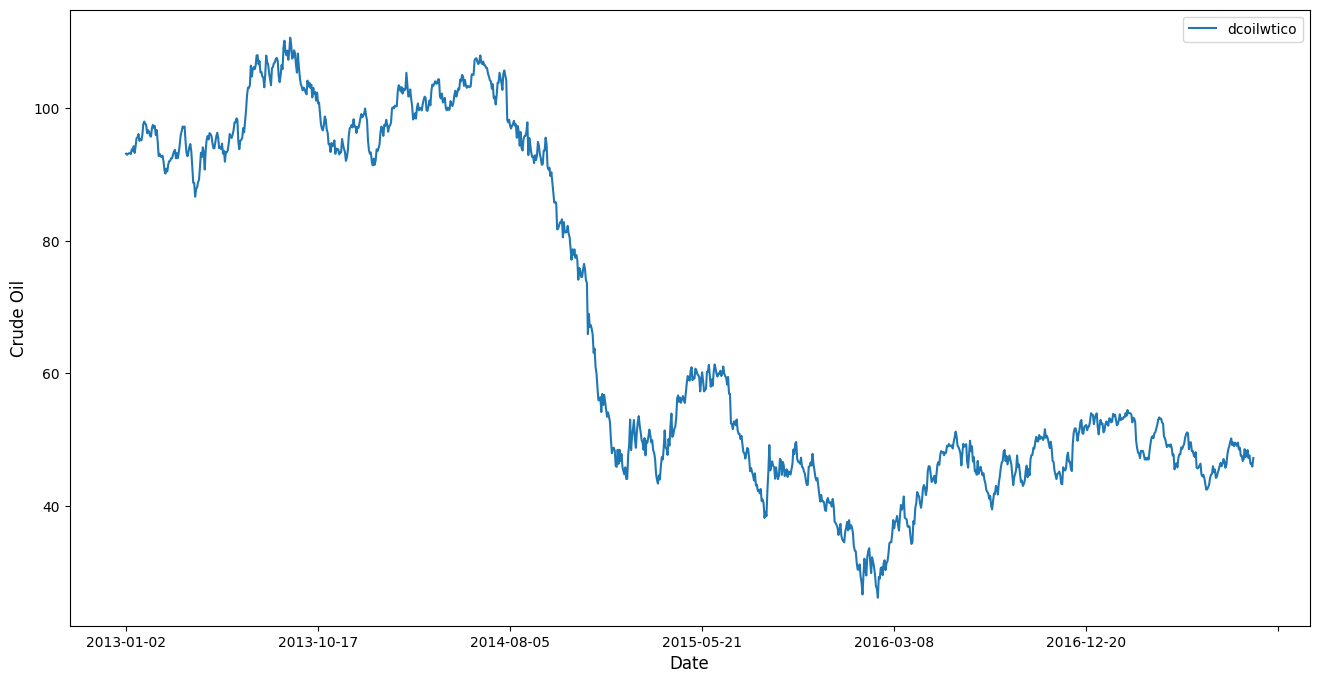

In [15]:
ax = data_oil.set_index('date').plot(figsize = (16, 8))
ax.set_xlabel('Date', fontsize = 'large')
ax.set_ylabel("Crude Oil", fontsize = 'large')

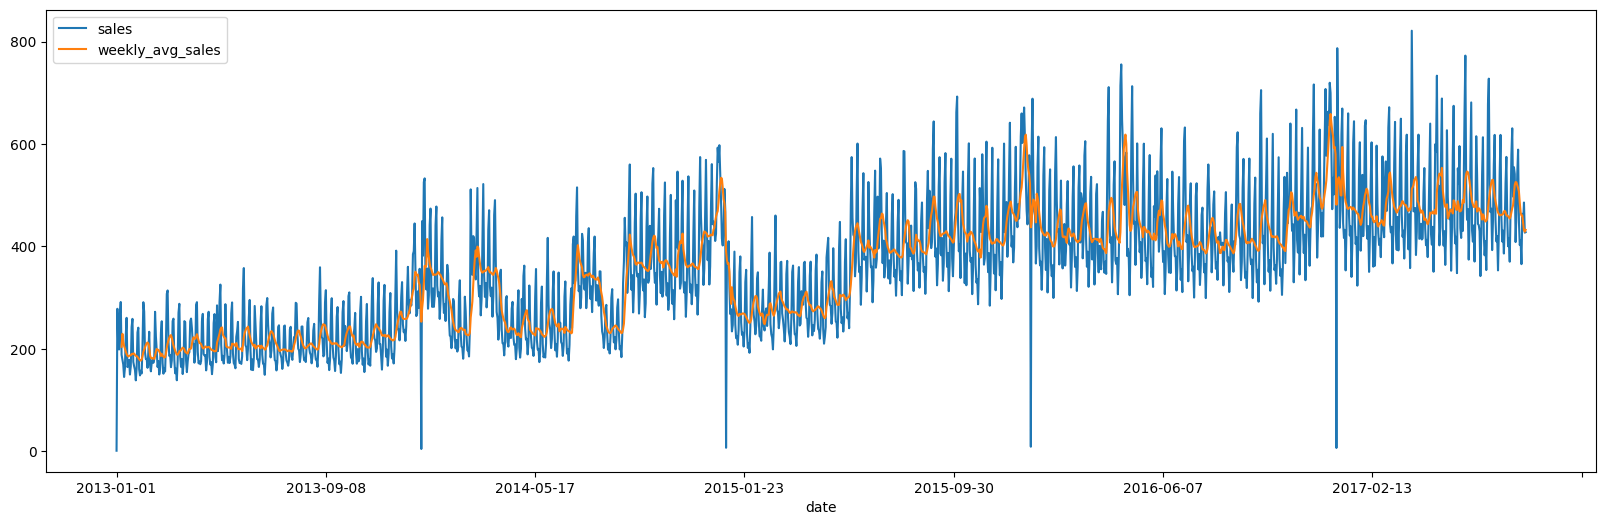

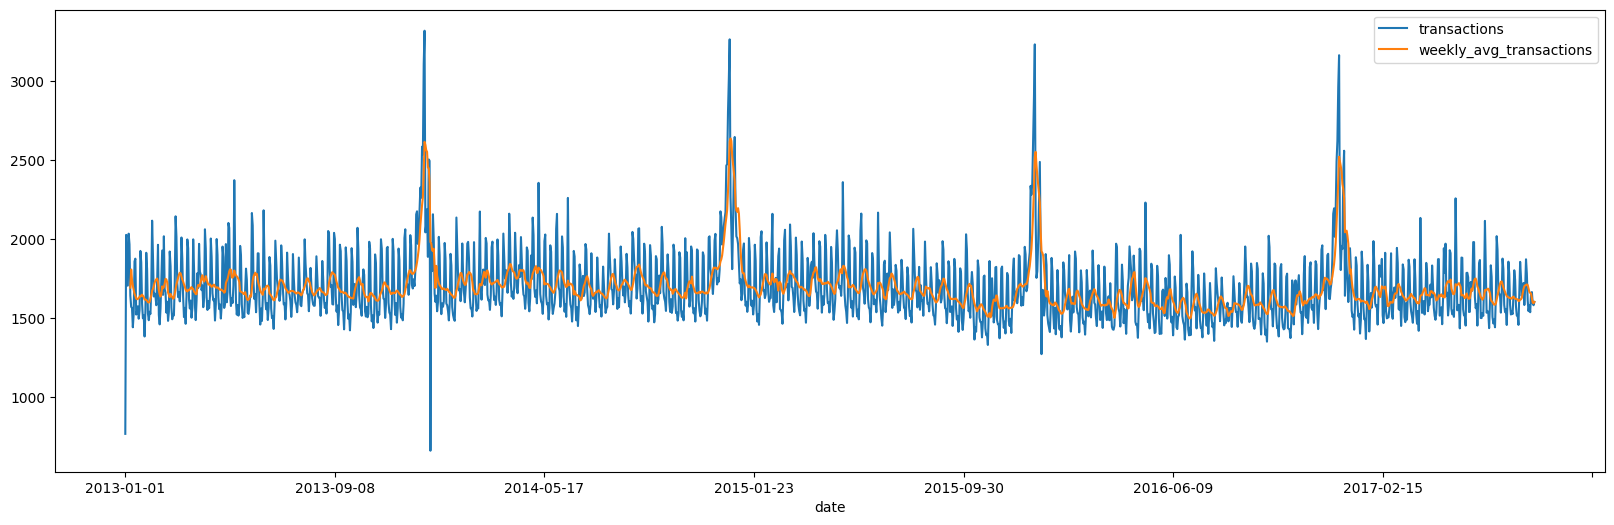

In [16]:
avg_sales = data_train.groupby('date').agg({'sales': 'mean'}).reset_index()

avg_sales['weekly_avg_sales'] = avg_sales['sales'].rolling(7).mean()
#ax1
ax1 = avg_sales.plot(x= 'date', y= ['sales', 'weekly_avg_sales'], figsize=(20,6))


avg_transactions = data_trans.groupby('date').agg({'transactions': 'mean'}).reset_index()

avg_transactions['weekly_avg_transactions'] = avg_transactions['transactions'].rolling(7).mean()

ax2 = avg_transactions.plot(x= 'date', y= ['transactions', 'weekly_avg_transactions'], figsize=(20,6))

In [17]:
avg_sales.head(10)

,date,sales,weekly_avg_sales
0,2013-01-01,1.409438,NaN
1,2013-01-02,278.390807,NaN
2,2013-01-03,202.840197,NaN
3,2013-01-04,198.911154,NaN
4,2013-01-05,267.873244,NaN
5,2013-01-06,291.636028,NaN
6,2013-01-07,188.621100,204.240281
7,2013-01-08,178.646340,229.559839
8,2013-01-09,169.770375,214.042634
9,2013-01-10,145.332213,205.827208


In [18]:
data_oil['date']=pd.to_datetime(data_oil['date'])

data_oil['sales']=avg_sales['sales']
data_oil['transactions'] = avg_transactions['transactions']
data_oil.corr()

,date,dcoilwtico,sales,transactions
date,1.000000,-0.838111,0.682367,-0.062617
dcoilwtico,-0.838111,1.000000,-0.500805,0.043190
sales,0.682367,-0.500805,1.000000,0.364270
transactions,-0.062617,0.043190,0.364270,1.000000


Correlation between oil and sales and transaction suggests that the country's economic status and everyday grocery consumption do not have a particular relationship.

# Let's check items that are most sold and the promotion to see which items influence the most for the total sales.

In [19]:
# print the unique family products
print(data_train.family.unique())

['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']


In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data_train['family_encoded'] = le.fit_transform(data_train['family'])

In [21]:
data_train.head()

,id,date,store_nbr,family,sales,onpromotion,family_encoded
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,0
1,1,2013-01-01,1,BABY CARE,0.0,0,1
2,2,2013-01-01,1,BEAUTY,0.0,0,2
3,3,2013-01-01,1,BEVERAGES,0.0,0,3
4,4,2013-01-01,1,BOOKS,0.0,0,4


In [22]:
categories = le.inverse_transform(data_train['family_encoded'])
categories

array(['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', ..., 'PRODUCE',
       'SCHOOL AND OFFICE SUPPLIES', 'SEAFOOD'], dtype=object)

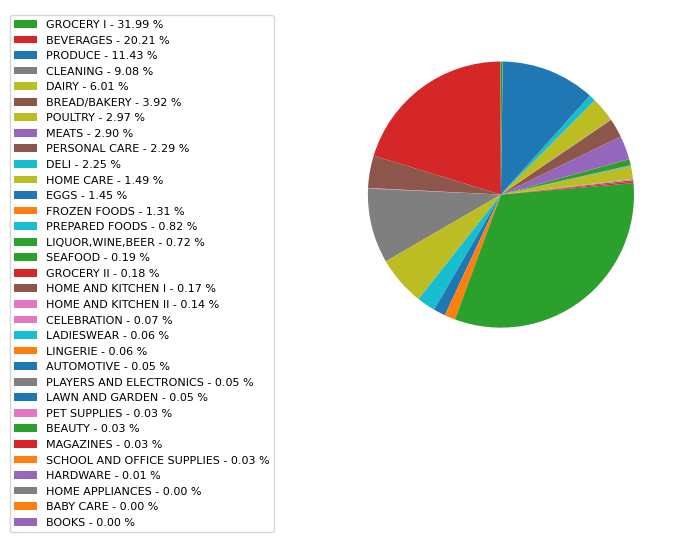

In [23]:
import matplotlib.pyplot as plt
data_grouped_family_types = data_train.groupby(['family_encoded'])[['sales', 'onpromotion']].mean()


data_grouped_family_types['%_s'] = 100 * data_grouped_family_types['sales'] / data_grouped_family_types['sales'].sum()
data_grouped_family_types['%_s'] = data_grouped_family_types['%_s'].round(decimals = 3)
data_grouped_family_types.index = le.inverse_transform(
    data_grouped_family_types.index
)

percent = 100 * data_grouped_family_types['sales'] / data_grouped_family_types['sales'].sum()
percent = percent.round(decimals = 3)
patches, texts = plt.pie(data_grouped_family_types['%_s'], startangle=90, radius=0.9)


labels_2 = [
    f'{i} - {j:.2f} %'
    for i, j in zip(data_grouped_family_types.index, percent)
]


sort_legend = True
if sort_legend:
    patches, labels, dummy =  zip(*sorted(zip(patches, labels_2, data_grouped_family_types['%_s']),
                                          key=lambda x: x[2],
                                          reverse=True))
    
plt.legend(patches, labels, loc='best', bbox_to_anchor=(-0.1, 1.),
           fontsize=8)

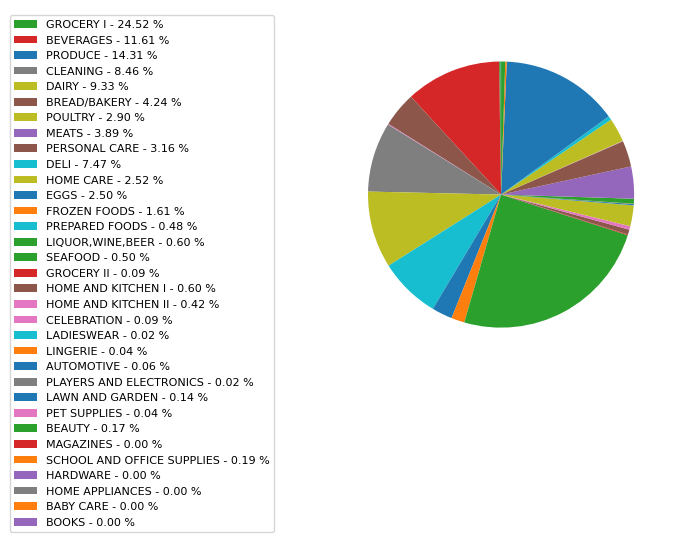

In [24]:
data_grouped_family_types['%_p'] = 100 * data_grouped_family_types['onpromotion'] / data_grouped_family_types['onpromotion'].sum()
data_grouped_family_types['%_p'] = data_grouped_family_types['%_p'].round(decimals = 3)

percent = 100 * data_grouped_family_types['onpromotion'] / data_grouped_family_types['onpromotion'].sum()
percent = percent.round(decimals = 3)
patches, texts = plt.pie(data_grouped_family_types['%_p'], startangle=90, radius=0.9)


labels_2 = [
    f'{i} - {j:.2f} %'
    for i, j in zip(data_grouped_family_types.index, percent)
]


sort_legend = True
if sort_legend:
    patches, labels, dummy =  zip(*sorted(zip(patches, labels_2, data_grouped_family_types['%_s']),
                                          key=lambda x: x[2],
                                          reverse=True))
    
plt.legend(patches, labels, loc='best', bbox_to_anchor=(-0.1, 1.),
           fontsize=8)

# So as we can see the most famous products are the Grocery, Beverages, cleaning, dairy.

In [25]:
data_train['date']=pd.to_datetime(data_train['date'])
data_train['day_of_week']=data_train['date'].dt.dayofweek
data_train['month']=data_train['date'].dt.month
data_train['year']=data_train['date'].dt.year

In [26]:
data_grouped_day = data_train.groupby(['day_of_week'])['sales'].mean()
data_grouped_month = data_train.groupby(['year'])['sales'].mean()
data_grouped_year = data_train.groupby(['month'])['sales'].mean()

<Axes: xlabel='day_of_week'>

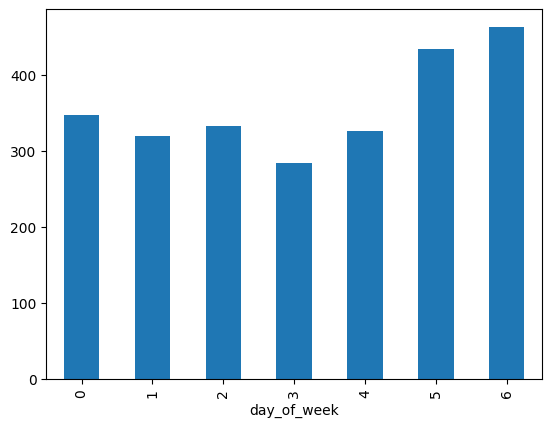

In [27]:
data_grouped_day.plot(kind='bar', stacked=True)

Saturday and Sunday has the highest sales.

<Axes: xlabel='year'>

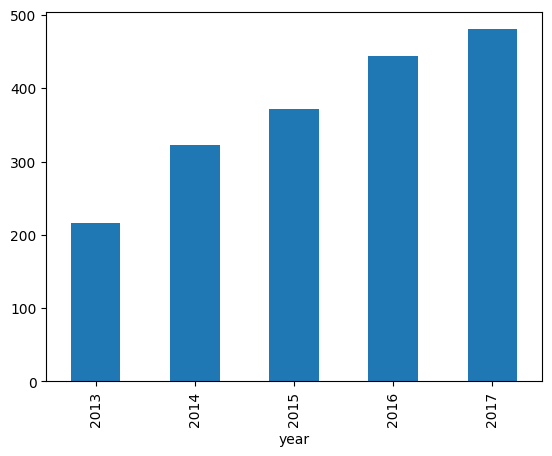

In [28]:
data_grouped_month.plot(kind='bar', stacked=True)

The sales are increasing during years.

<Axes: xlabel='month'>

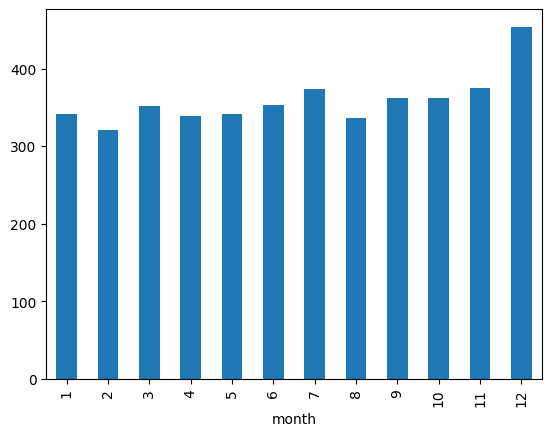

In [29]:
data_grouped_year.plot(kind='bar',stacked = True)

December is the month with most sales.

# Check the holiday data

In [30]:
data_holi.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [31]:
print(data_holi.type.unique())

['Holiday' 'Transfer' 'Additional' 'Bridge' 'Work Day' 'Event']


In [32]:
avg_sales = data_train.groupby('date').agg({'sales':'mean'})
day_type = data_holi[['date','type']]

day_type['date']=pd.to_datetime(day_type['date'])
# avg_sales['date']=pd.to_datetime(avg_sales['date'])

# We can connect the holidays data with train data through the date column
df_merged = pd.merge_asof(avg_sales,day_type,on='date')


/tmp/ipykernel_16/1029826872.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  day_type['date']=pd.to_datetime(day_type['date'])


In [33]:
df_1 = df_merged.groupby(['type'])['sales'].mean()

Text(0.5, 1.0, 'Holiday sales per category')

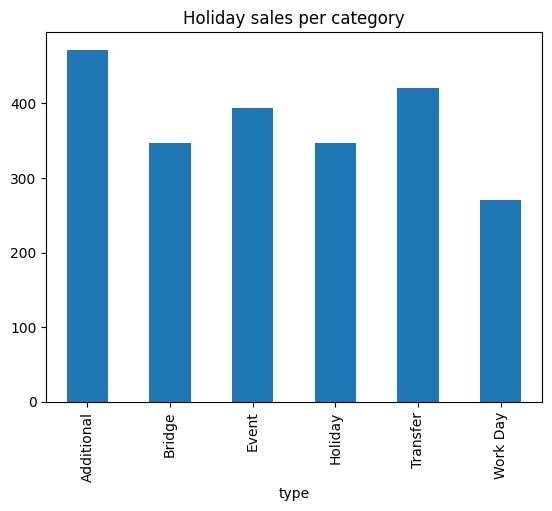

In [34]:
df_1.plot(kind='bar')
plt.title('Holiday sales per category')